In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
two_blobs= pd.read_csv('cluster_two_blobs.csv')
two_blobs

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215
...,...,...
995,-9.895227,-6.644544
996,-9.544007,-6.060362
997,0.713958,1.560460
998,0.954444,0.889178


In [14]:
two_blobs_outliers= pd.read_csv('cluster_two_blobs_outliers.csv')
two_blobs_outliers

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215
...,...,...
998,0.954444,0.889178
999,-8.867767,-5.635758
1000,-4.000000,-2.000000
1001,0.000000,-8.000000


In [19]:
def find_labels(model,data):
    labels= model.fit_predict(data)
    sns.scatterplot(data=data,x='X1',y='X2',hue=labels,palette='Set1')

In [20]:
from sklearn.cluster import DBSCAN

In [21]:
dbscan= DBSCAN()

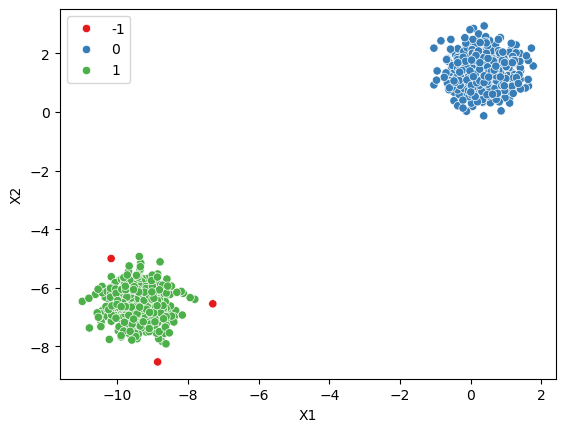

In [22]:
find_labels(model=dbscan, data=two_blobs)

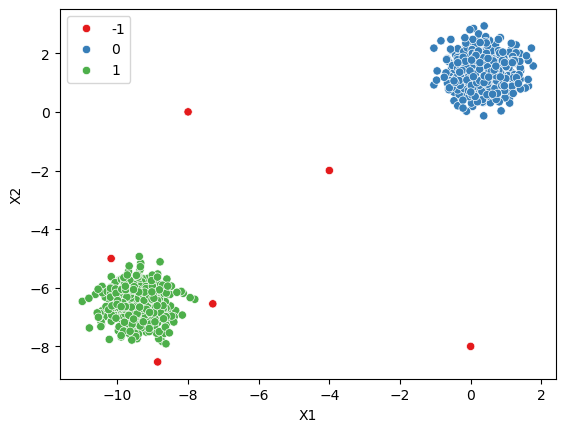

In [23]:
find_labels(model=dbscan, data=two_blobs_outliers)

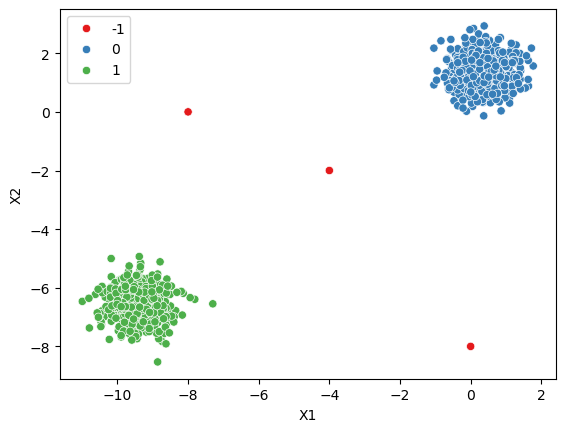

In [24]:
dbscan= DBSCAN(eps=1)
find_labels(model=dbscan, data=two_blobs_outliers)

In [27]:
dbscan.labels_ # last three -1 are for the three outlier points

array([ 0,  1,  0, ..., -1, -1, -1])

In [29]:
np.sum(dbscan.labels_==-1)

np.int64(3)

In [33]:
np.sum(dbscan.labels_==-1)*100/len(dbscan.labels_) #this tells us about the number of outliers

np.float64(0.29910269192422734)

### Charting Epsilon Values

In [35]:
np.linspace(0.001,10,100)

array([1.000e-03, 1.020e-01, 2.030e-01, 3.040e-01, 4.050e-01, 5.060e-01,
       6.070e-01, 7.080e-01, 8.090e-01, 9.100e-01, 1.011e+00, 1.112e+00,
       1.213e+00, 1.314e+00, 1.415e+00, 1.516e+00, 1.617e+00, 1.718e+00,
       1.819e+00, 1.920e+00, 2.021e+00, 2.122e+00, 2.223e+00, 2.324e+00,
       2.425e+00, 2.526e+00, 2.627e+00, 2.728e+00, 2.829e+00, 2.930e+00,
       3.031e+00, 3.132e+00, 3.233e+00, 3.334e+00, 3.435e+00, 3.536e+00,
       3.637e+00, 3.738e+00, 3.839e+00, 3.940e+00, 4.041e+00, 4.142e+00,
       4.243e+00, 4.344e+00, 4.445e+00, 4.546e+00, 4.647e+00, 4.748e+00,
       4.849e+00, 4.950e+00, 5.051e+00, 5.152e+00, 5.253e+00, 5.354e+00,
       5.455e+00, 5.556e+00, 5.657e+00, 5.758e+00, 5.859e+00, 5.960e+00,
       6.061e+00, 6.162e+00, 6.263e+00, 6.364e+00, 6.465e+00, 6.566e+00,
       6.667e+00, 6.768e+00, 6.869e+00, 6.970e+00, 7.071e+00, 7.172e+00,
       7.273e+00, 7.374e+00, 7.475e+00, 7.576e+00, 7.677e+00, 7.778e+00,
       7.879e+00, 7.980e+00, 8.081e+00, 8.182e+00, 

In [41]:
outlier_percent=[]
number_of_outlier= []

for eps in np.linspace(0.001,3,100):
    dbscan= DBSCAN(eps=eps)
    dbscan.fit(two_blobs_outliers)


    number_of_outlier.append(np.sum(dbscan.labels_== -1))

    outlier_percent.append(100*np.sum(dbscan.labels_== -1)/len(dbscan.labels_))

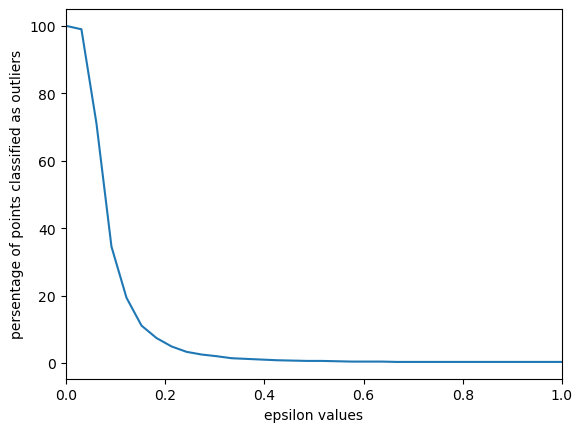

In [42]:
sns.lineplot(x=np.linspace(0.001,3,100),y=outlier_percent)
plt.ylabel("persentage of points classified as outliers")
plt.xlabel("epsilon values")
plt.xlim(0,1)
plt.show()

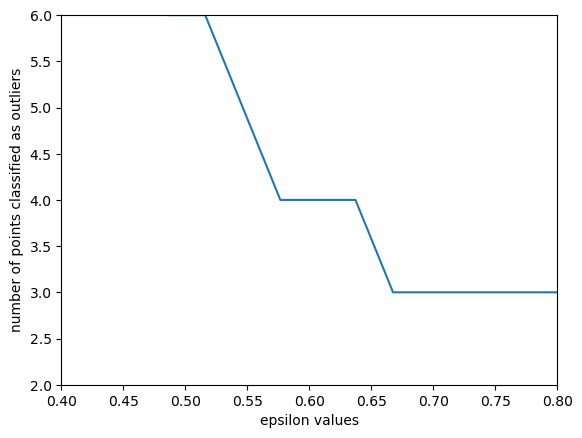

In [46]:
sns.lineplot(x=np.linspace(0.001,3,100),y=number_of_outlier)
plt.ylabel("number of points classified as outliers")
plt.xlabel("epsilon values")
plt.xlim(0.4,0.8)
plt.ylim(2,6)
plt.show()

# Minimum no. of samples

In [49]:
outlier_percent=[]


for n in np.arange(1,100):
    dbscan= DBSCAN(min_samples=n)
    dbscan.fit(two_blobs_outliers)

    outlier_percent.append(100*np.sum(dbscan.labels_== -1)/len(dbscan.labels_))

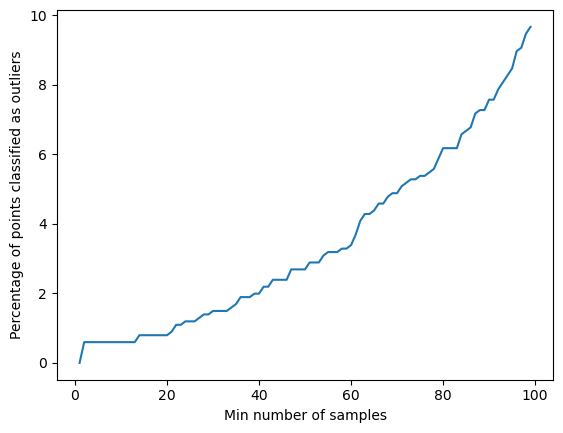

In [50]:
sns.lineplot(x=np.arange(1,100),y=outlier_percent)
plt.ylabel("Percentage of points classified as outliers")
plt.xlabel("Min number of samples")
plt.show()

In [51]:
2*two_blobs_outliers.shape[1]

4

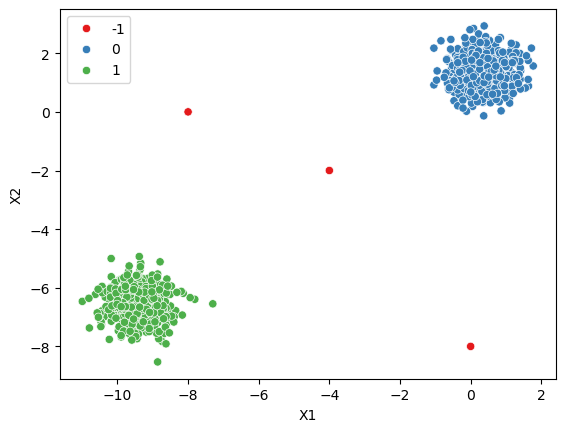

In [52]:
dbscan= DBSCAN(min_samples=2*two_blobs_outliers.shape[1], eps=0.75)
find_labels(dbscan,two_blobs_outliers)

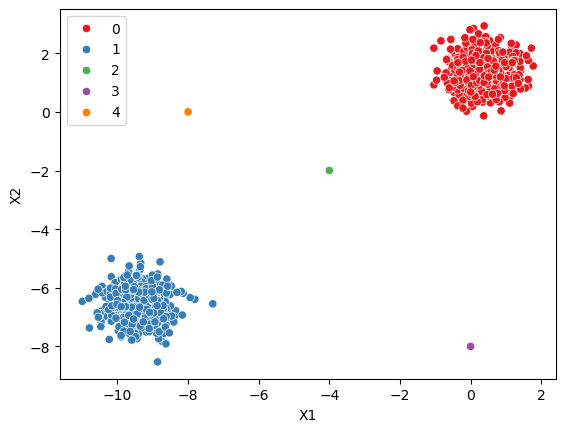

In [53]:
dbscan= DBSCAN(min_samples=1, eps=0.75)
find_labels(dbscan,two_blobs_outliers)